# 05. Análisis de Resultados y Sesgos
## Objetivo
Estudiar cuándo el modelo funciona bien y cuándo falla:
- Calibración probabilística por resultado (H, D, A)
- Hit rate vs cuota implícita: ¿el modelo sobreestima?
- Análisis temporal: ¿hay deriva entre temporadas?
- Segmentación de la estrategia: ¿en qué partidos apuesta y por qué?
- Detección de sesgos: efecto local, cuotas altas/bajas, parte de temporada


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar resultados del backtest
bets_path    = '../results/backtest_master_bets.csv'
seasons_path = '../results/backtest_master_seasons.csv'

df_bets    = pd.read_csv(bets_path)
df_seasons = pd.read_csv(seasons_path)
df_bets['Date'] = pd.to_datetime(df_bets['Date'])

print(f'Total apuestas: {len(df_bets)}')
print(f'Temporadas:     {sorted(df_bets["Season"].unique())}')
print(df_bets.head())


Total apuestas: 367
Temporadas:     [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
   Season       Date    HomeTeam    AwayTeam  Bet_Type  Odds   P_Model  \
0    2012 2012-08-18    Mallorca     Espanol         1  2.00  0.573125   
1    2012 2012-08-20   Vallecano     Granada         1  2.20  0.551232   
2    2012 2012-08-20    Zaragoza  Valladolid         1  2.15  0.490409   
3    2012 2012-08-27  Valladolid     Levante         1  2.05  0.551878   
4    2012 2012-09-01    Mallorca    Sociedad         1  2.10  0.533334   

         EV    Won  Flat_Stake  Flat_Profit  Kelly_Stake  Kelly_Profit  \
0  0.146251   True        10.0         10.0    36.562743     36.562743   
1  0.212709   True        10.0         12.0    44.314463     53.177355   
2  0.054379  False        10.0        -10.0    11.821559    -11.821559   
3  0.131349   

## 1. Calibración — ¿Las probabilidades son fiables?

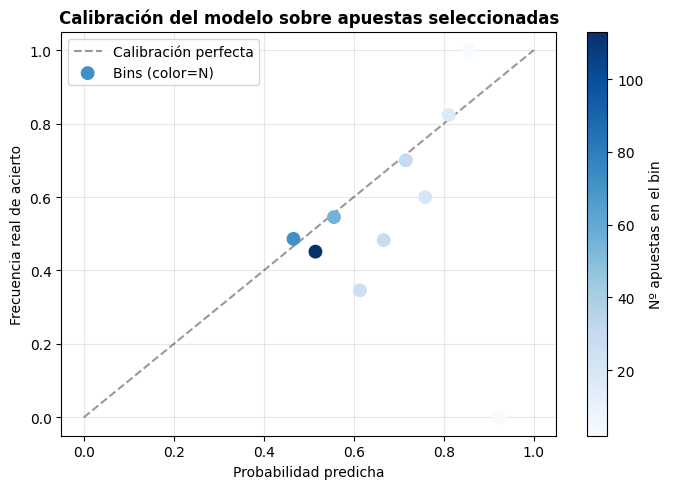

         P_bin  P_media  Hit_real   N
(0.436, 0.487] 0.465998  0.486111  72
(0.487, 0.537] 0.514804  0.451327 113
(0.537, 0.587] 0.556078  0.545455  55
(0.587, 0.638] 0.613829  0.346154  26
(0.638, 0.688] 0.666458  0.482759  29
(0.688, 0.738] 0.715543  0.700000  30
(0.738, 0.788] 0.758816  0.600000  20
(0.788, 0.838] 0.811030  0.823529  17
(0.838, 0.888] 0.854071  1.000000   3
(0.888, 0.938] 0.923889  0.000000   2


In [63]:
# Dividir apuestas en deciles de probabilidad y calcular hit rate real
fig, ax = plt.subplots(figsize=(7, 5))

n_bins = 10
bins   = np.linspace(df_bets['P_Model'].min(), df_bets['P_Model'].max(), n_bins+1)
df_bets['P_bin'] = pd.cut(df_bets['P_Model'], bins=bins, include_lowest=True)
calib = df_bets.groupby('P_bin', observed=True).agg(
    P_media=('P_Model','mean'),
    Hit_real=('Won','mean'),
    N=('Won','count')
).reset_index()

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Calibración perfecta')
sc = ax.scatter(calib['P_media'], calib['Hit_real'], c=calib['N'],
                cmap='Blues', s=80, zorder=5, label='Bins (color=N)')
plt.colorbar(sc, ax=ax, label='Nº apuestas en el bin')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Frecuencia real de acierto')
ax.set_title('Calibración del modelo sobre apuestas seleccionadas', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/analisis_calibracion.png', dpi=120, bbox_inches='tight')
plt.show()
print(calib[['P_bin','P_media','Hit_real','N']].to_string(index=False))


## 2. Hit rate por rango de cuota
¿Captura el modelo edge en todos los rangos de cuota, o solo en algunos?


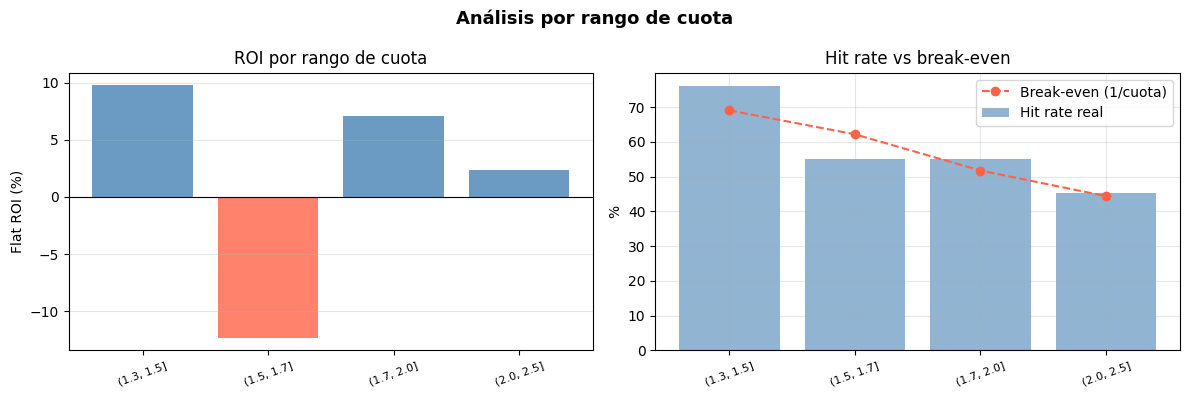

  Odds_bin   N      Hit  Flat_ROI       BE
(1.3, 1.5]  46 0.760870  0.097609 0.690898
(1.5, 1.7]  40 0.550000 -0.123250 0.621987
(1.7, 2.0]  49 0.551020  0.071224 0.517751
(2.0, 2.5] 232 0.452586  0.023190 0.444045


In [64]:
odds_bins = [1.0, 1.30, 1.50, 1.70, 2.00, 2.50, 3.00, 4.00, 10.0]
df_bets['Odds_bin'] = pd.cut(df_bets['Odds'], bins=odds_bins, include_lowest=True)

by_odds = df_bets.groupby('Odds_bin', observed=True).agg(
    N=('Won','count'),
    Hit=('Won','mean'),
    Flat_ROI=('Flat_Profit', lambda x: x.sum() / (len(x) * 10.0)),
    Odds_media=('Odds','mean')
).reset_index()

# Break-even: 1 / odds_media
by_odds['BE'] = 1.0 / by_odds['Odds_media']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['steelblue' if r > 0 else 'tomato' for r in by_odds['Flat_ROI']]
axes[0].bar(range(len(by_odds)), by_odds['Flat_ROI']*100, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(by_odds)))
axes[0].set_xticklabels([str(b) for b in by_odds['Odds_bin']], rotation=20, fontsize=8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Flat ROI (%)'); axes[0].set_title('ROI por rango de cuota'); axes[0].grid(axis='y',alpha=0.3)

axes[1].bar(range(len(by_odds)), by_odds['Hit']*100, color='steelblue', alpha=0.6, label='Hit rate real')
axes[1].plot(range(len(by_odds)), by_odds['BE']*100, 'o--', color='tomato', label='Break-even (1/cuota)')
axes[1].set_xticks(range(len(by_odds)))
axes[1].set_xticklabels([str(b) for b in by_odds['Odds_bin']], rotation=20, fontsize=8)
axes[1].set_ylabel('%'); axes[1].set_title('Hit rate vs break-even'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Análisis por rango de cuota', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_por_odds.png', dpi=120, bbox_inches='tight')
plt.show()
print(by_odds[['Odds_bin','N','Hit','Flat_ROI','BE']].to_string(index=False))


## 3. Deriva temporal — ¿El modelo pierde potencia con el tiempo?

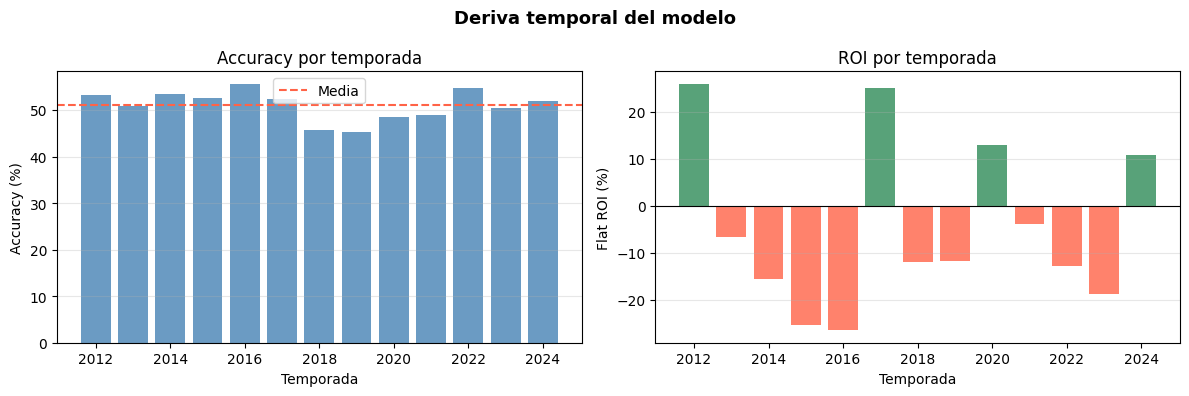

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

seasons = df_seasons['Season'].astype(int)
axes[0].bar(seasons, df_seasons['Accuracy']*100, color='steelblue', alpha=0.8)
axes[0].axhline(df_seasons['Accuracy'].mean()*100, color='tomato', linestyle='--', label='Media')
axes[0].set_xlabel('Temporada'); axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Accuracy por temporada')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

colors = ['seagreen' if r > 0 else 'tomato' for r in df_seasons['Flat_ROI']]
axes[1].bar(seasons, df_seasons['Flat_ROI']*100, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Temporada'); axes[1].set_ylabel('Flat ROI (%)'); axes[1].set_title('ROI por temporada')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Deriva temporal del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_deriva_temporal.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Estacionalidad — ¿Hay meses donde el modelo es mejor?
Hipótesis: a principio de temporada (sep–oct) hay más incertidumbre; al final (abr–may) los equipos
están más asentados y el modelo podría ser más preciso.


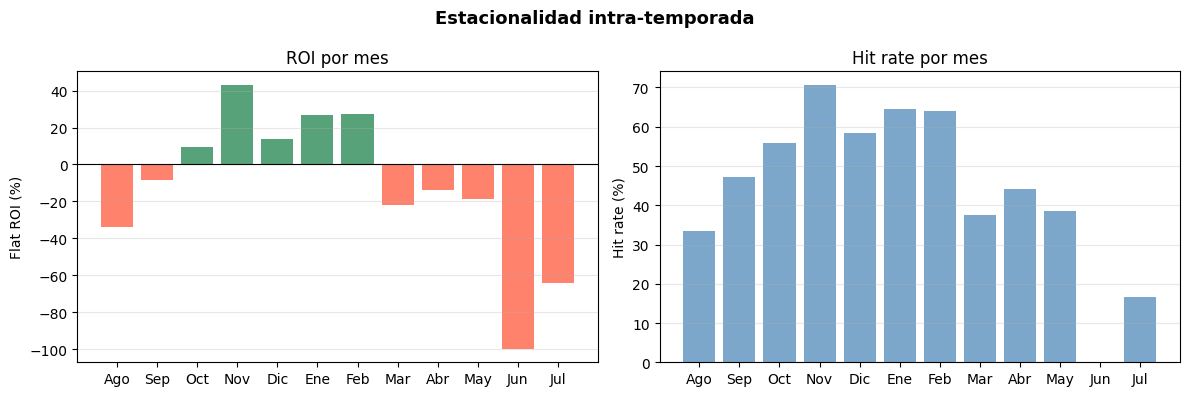

In [66]:
df_bets['Month'] = df_bets['Date'].dt.month
monthly = df_bets.groupby('Month').agg(
    N=('Won','count'),
    Hit=('Won','mean'),
    ROI=('Flat_Profit', lambda x: x.sum() / (len(x) * 10.0))
).reset_index()

month_names = {8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic',
               1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul'}
monthly['Month_name'] = monthly['Month'].map(month_names)
# Ordenar por calendario de temporada (ago->jul)
season_order = [8,9,10,11,12,1,2,3,4,5,6,7]
monthly['order'] = monthly['Month'].map({m:i for i,m in enumerate(season_order)})
monthly = monthly.sort_values('order')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['seagreen' if r > 0 else 'tomato' for r in monthly['ROI']]
axes[0].bar(range(len(monthly)), monthly['ROI']*100, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(monthly))); axes[0].set_xticklabels(monthly['Month_name'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Flat ROI (%)'); axes[0].set_title('ROI por mes'); axes[0].grid(axis='y',alpha=0.3)

axes[1].bar(range(len(monthly)), monthly['Hit']*100, color='steelblue', alpha=0.7)
axes[1].set_xticks(range(len(monthly))); axes[1].set_xticklabels(monthly['Month_name'])
axes[1].set_ylabel('Hit rate (%)'); axes[1].set_title('Hit rate por mes'); axes[1].grid(axis='y',alpha=0.3)

plt.suptitle('Estacionalidad intra-temporada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_estacionalidad.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Sesgo de tipo de apuesta — ¿Locales o visitantes?

Breakdown por tipo de apuesta:
 Bet_Type   N      Hit  Flat_ROI  Avg_Odds   Avg_EV
        1 347 0.518732  0.034409  2.050029 0.146193
        2  20 0.450000 -0.175500  1.832000 0.171584


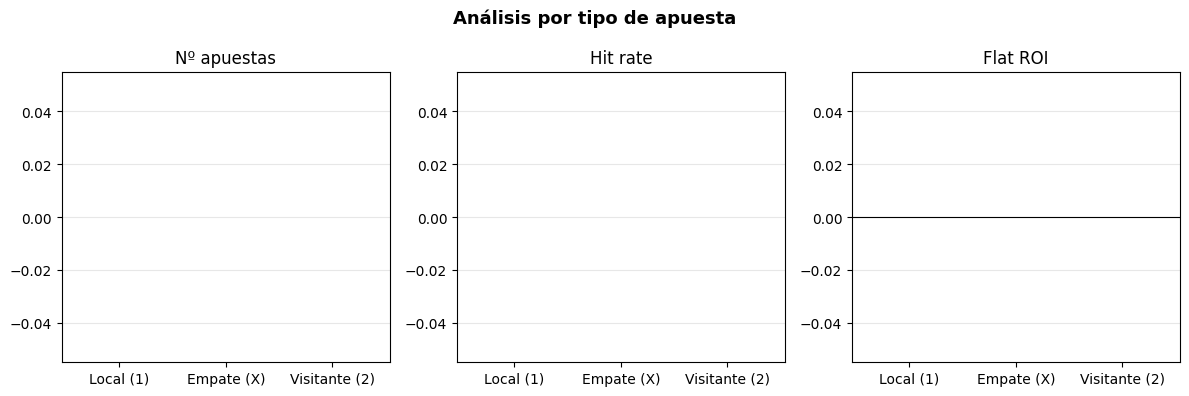

In [67]:
by_type = df_bets.groupby('Bet_Type').agg(
    N=('Won','count'),
    Hit=('Won','mean'),
    Flat_ROI=('Flat_Profit', lambda x: x.sum() / (len(x) * 10.0)),
    Avg_Odds=('Odds','mean'),
    Avg_EV=('EV','mean')
).reset_index()

print('Breakdown por tipo de apuesta:')
print(by_type.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = {'1': 'steelblue', 'X': 'goldenrod', '2': 'tomato'}
for ax, col, title in zip(axes,
    ['N', 'Hit', 'Flat_ROI'],
    ['Nº apuestas', 'Hit rate', 'Flat ROI']):
    vals  = [by_type.loc[by_type['Bet_Type']==bt, col].values[0]
             if bt in by_type['Bet_Type'].values else 0 for bt in ['1','X','2']]
    if col in ['Hit','Flat_ROI']:
        vals = [v*100 for v in vals]
    ax.bar(['Local (1)','Empate (X)','Visitante (2)'], vals,
           color=[colors['1'], colors['X'], colors['2']], alpha=0.8)
    if col == 'Flat_ROI':
        ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Análisis por tipo de apuesta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_por_tipo.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Análisis de las peores temporadas

In [68]:
# Identificar temporadas con ROI negativo y analizar que paso
bad_seasons = df_seasons[df_seasons['Flat_ROI'] < 0]['Season'].tolist()
print(f'Temporadas negativas: {bad_seasons}')

for s in bad_seasons:
    sub = df_bets[df_bets['Season'] == s]
    if sub.empty: continue
    roi = sub['Flat_Profit'].sum() / (len(sub) * 10.0)
    print(f'\n  --- Temporada {int(s)} ---')
    print(f'  Apuestas: {len(sub)} | Hit: {sub["Won"].mean():.1%} | ROI: {roi:+.2%}')
    print(f'  Por tipo:')
    for bt in sub['Bet_Type'].unique():
        ss = sub[sub['Bet_Type']==bt]
        r  = ss['Flat_Profit'].sum() / (len(ss)*10.0)
        print(f'    {bt}: {len(ss)} bets, hit={ss["Won"].mean():.1%}, ROI={r:+.2%}')
    # Maxima racha perdedora
    streak = mx = 0
    for p in sub['Flat_Profit']:
        streak = streak+1 if p < 0 else 0
        mx = max(mx, streak)
    print(f'  Max racha perdedora: {mx} apuestas')


Temporadas negativas: [2013, 2014, 2015, 2016, 2018, 2019, 2021, 2022, 2023]

  --- Temporada 2013 ---
  Apuestas: 16 | Hit: 43.8% | ROI: -6.69%
  Por tipo:
    1: 16 bets, hit=43.8%, ROI=-6.69%
  Max racha perdedora: 3 apuestas

  --- Temporada 2014 ---
  Apuestas: 15 | Hit: 40.0% | ROI: -15.67%
  Por tipo:
    1: 15 bets, hit=40.0%, ROI=-15.67%
  Max racha perdedora: 4 apuestas

  --- Temporada 2015 ---
  Apuestas: 15 | Hit: 40.0% | ROI: -25.40%
  Por tipo:
    1: 14 bets, hit=35.7%, ROI=-33.71%
    2: 1 bets, hit=100.0%, ROI=+91.00%
  Max racha perdedora: 5 apuestas

  --- Temporada 2016 ---
  Apuestas: 15 | Hit: 33.3% | ROI: -26.53%
  Por tipo:
    1: 14 bets, hit=35.7%, ROI=-21.29%
    2: 1 bets, hit=0.0%, ROI=-100.00%
  Max racha perdedora: 5 apuestas

  --- Temporada 2018 ---
  Apuestas: 37 | Hit: 45.9% | ROI: -11.92%
  Por tipo:
    1: 33 bets, hit=45.5%, ROI=-11.91%
    2: 4 bets, hit=50.0%, ROI=-12.00%
  Max racha perdedora: 4 apuestas

  --- Temporada 2019 ---
  Apuestas: 29

## 8. Calibración avanzada — ECE y sobreconfianza por temporada
La celda 1 muestra calibración agregada. Aquí medimos:
- **ECE** (Expected Calibration Error): desviación media entre probabilidades predichas y frecuencias reales.
- **Sobreconfianza por temporada**: en qué años el modelo creyó tener más edge del real.
- **Por qué Kelly falla**: si el modelo sobreestima P, apuesta demasiado y la varianza le destruye.

Los datos provienen del backtest principal 2012–2024 (kill switch activo, 367 apuestas).


In [69]:
def ece(p_pred, y_true, n_bins=10):
    """Expected Calibration Error ponderado por tamaño de bin."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece_val = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p_pred >= lo) & (p_pred < hi)
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = p_pred[mask].mean()
        ece_val += mask.mean() * abs(conf - acc)
    return ece_val

p = df_bets['P_Model'].values
y = df_bets['Won'].values.astype(int)

print(f'ECE global (backtest 2015-2024): {ece(p, y):.4f}')
print(f'Referencia: < 0.03 = bien calibrado | > 0.05 = sobreconfianza significativa')
print()

over = df_bets.groupby('Season').apply(
    lambda g: pd.Series({
        'P_media':  round(g['P_Model'].mean(), 4),
        'Hit_real': round(g['Won'].mean(), 4),
        'Overconf': round(g['P_Model'].mean() - g['Won'].mean(), 4),
        'ECE':      round(ece(g['P_Model'].values, g['Won'].values.astype(int)), 4),
        'N_Bets':   len(g),
    })
).reset_index()

print(over.to_string(index=False))


ECE global (backtest 2015-2024): 0.0699
Referencia: < 0.03 = bien calibrado | > 0.05 = sobreconfianza significativa

 Season  P_media  Hit_real  Overconf    ECE  N_Bets
   2012   0.5327    0.5846   -0.0519 0.0597    65.0
   2013   0.5738    0.4375    0.1363 0.1833    16.0
   2014   0.5602    0.4000    0.1602 0.2447    15.0
   2015   0.6519    0.4000    0.2519 0.2931    15.0
   2016   0.5341    0.3333    0.2008 0.2008    15.0
   2017   0.5703    0.6154   -0.0451 0.1737    39.0
   2018   0.5846    0.4595    0.1252 0.1441    37.0
   2019   0.5739    0.4483    0.1256 0.1933    29.0
   2020   0.6390    0.6471   -0.0081 0.0985    34.0
   2021   0.6173    0.5333    0.0840 0.1615    45.0
   2022   0.6144    0.4667    0.1477 0.2064    15.0
   2023   0.5609    0.4000    0.1609 0.1698    15.0
   2024   0.5477    0.5185    0.0291 0.1419    27.0


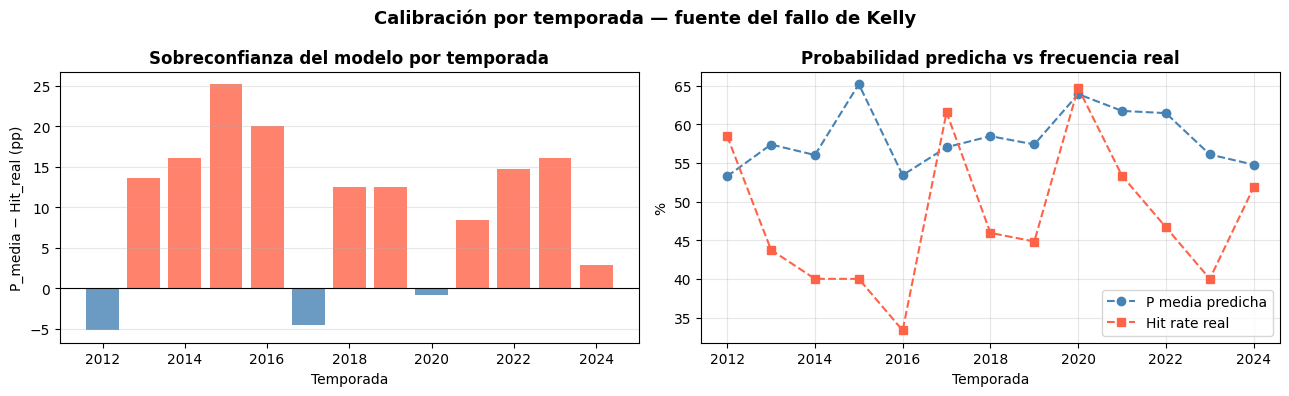

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['tomato' if v > 0 else 'steelblue' for v in over['Overconf']]
axes[0].bar(over['Season'].astype(int), over['Overconf']*100, color=colors, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Temporada')
axes[0].set_ylabel('P_media − Hit_real (pp)')
axes[0].set_title('Sobreconfianza del modelo por temporada', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(over['Season'].astype(int), over['P_media']*100,  'o--',
             color='steelblue', label='P media predicha')
axes[1].plot(over['Season'].astype(int), over['Hit_real']*100, 's--',
             color='tomato',    label='Hit rate real')
axes[1].set_xlabel('Temporada'); axes[1].set_ylabel('%')
axes[1].set_title('Probabilidad predicha vs frecuencia real', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Calibración por temporada — fuente del fallo de Kelly',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_sobreconfianza.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Análisis profundo de 2018 — ¿Mala suerte o cambio estructural?
2018 es una de las temporadas negativas: –11.92% ROI, 45.9% hit rate con 37 apuestas (kill switch activo).
Investigamos si las distribuciones de las apuestas ese año eran distintas al resto
(señal de cambio estructural) o estadísticamente iguales (señal de mala suerte pura).


In [71]:
df_18   = df_bets[df_bets['Season'] == 2018].copy()
df_rest = df_bets[df_bets['Season'] != 2018].copy()
df_18['Date'] = pd.to_datetime(df_18['Date'])

print(f'Apuestas 2018 : {len(df_18)}  |  Hit: {df_18["Won"].mean():.1%}')
print(f'P_model media : {df_18["P_Model"].mean():.1%}')
print(f'Sobreconfianza: {(df_18["P_Model"].mean() - df_18["Won"].mean())*100:+.1f} pp')
print(f'ROI           : {df_18["Flat_Profit"].sum()/(len(df_18)*10):+.2%}')
print()

print('--- Por tipo ---')
for bt in df_18['Bet_Type'].unique():
    s = df_18[df_18['Bet_Type'] == bt]
    r = s['Flat_Profit'].sum() / (len(s) * 10)
    print(f'  {bt}: {len(s)} bets | hit={s["Won"].mean():.1%} | '
          f'ROI={r:+.2%} | avg odds={s["Odds"].mean():.2f}')

print()
print('--- Evolución mensual ---')
df_18['Month'] = df_18['Date'].dt.month
for m, g in df_18.groupby('Month'):
    r = g['Flat_Profit'].sum() / (len(g) * 10)
    print(f'  Mes {m:2d}: {len(g):2d} bets | hit={g["Won"].mean():.1%} | ROI={r:+.2%}')


Apuestas 2018 : 37  |  Hit: 45.9%
P_model media : 58.5%
Sobreconfianza: +12.5 pp
ROI           : -11.92%

--- Por tipo ---
  1: 33 bets | hit=45.5% | ROI=-11.91% | avg odds=2.05
  2: 4 bets | hit=50.0% | ROI=-12.00% | avg odds=1.79

--- Evolución mensual ---
  Mes  1:  6 bets | hit=33.3% | ROI=-26.67%
  Mes  2:  6 bets | hit=50.0% | ROI=+8.33%
  Mes  3:  3 bets | hit=33.3% | ROI=-33.33%
  Mes  4:  8 bets | hit=37.5% | ROI=-35.62%
  Mes  5:  1 bets | hit=0.0% | ROI=-100.00%
  Mes  8:  1 bets | hit=0.0% | ROI=-100.00%
  Mes  9:  3 bets | hit=66.7% | ROI=+14.67%
  Mes 10:  3 bets | hit=33.3% | ROI=-28.67%
  Mes 11:  2 bets | hit=100.0% | ROI=+72.00%
  Mes 12:  4 bets | hit=75.0% | ROI=+38.00%


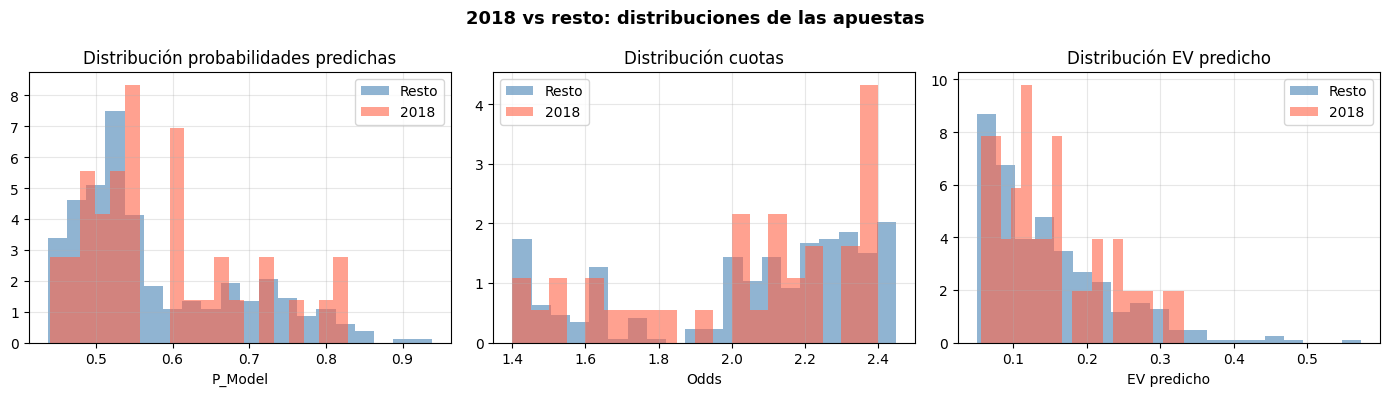

KS P_Model   : stat=0.149  p=0.407  -> iguales (mala suerte)
KS EV        : stat=0.139  p=0.496  -> iguales (mala suerte)
KS Odds      : stat=0.082  p=0.963  -> iguales (mala suerte)


In [72]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_rest['P_Model'], bins=20, alpha=0.6, color='steelblue',
             label='Resto', density=True)
axes[0].hist(df_18['P_Model'],   bins=20, alpha=0.6, color='tomato',
             label='2018',  density=True)
axes[0].set_xlabel('P_Model')
axes[0].set_title('Distribución probabilidades predichas')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(df_rest['Odds'], bins=20, alpha=0.6, color='steelblue',
             label='Resto', density=True)
axes[1].hist(df_18['Odds'],   bins=20, alpha=0.6, color='tomato',
             label='2018',  density=True)
axes[1].set_xlabel('Odds')
axes[1].set_title('Distribución cuotas')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(df_rest['EV'], bins=20, alpha=0.6, color='steelblue',
             label='Resto', density=True)
axes[2].hist(df_18['EV'],   bins=20, alpha=0.6, color='tomato',
             label='2018',  density=True)
axes[2].set_xlabel('EV predicho')
axes[2].set_title('Distribución EV predicho')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('2018 vs resto: distribuciones de las apuestas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/analisis_2018.png', dpi=120, bbox_inches='tight')
plt.show()

# Test KS: ¿son distribuciones distintas?
for col in ['P_Model', 'EV', 'Odds']:
    stat, pval = stats.ks_2samp(df_18[col], df_rest[col])
    sig = 'DISTINTAS (cambio estructural)' if pval < 0.05 else 'iguales (mala suerte)'
    print(f'KS {col:10s}: stat={stat:.3f}  p={pval:.3f}  -> {sig}')


## 10. Significancia estadística del edge
Con ~28 apuestas/año de media (kill switch activo, 367 bets en 13 temporadas), ¿es el +2.30% ROI significativamente distinto de 0?
Usamos bootstrap (no paramétrico) y test binomial.


ROI observado    : +2.30%
IC 95% bootstrap : [-9.88%, +12.36%]
(Bootstrap por temporada — respeta dependencia intra-temporada)
Contiene 0?      : SI -> no significativo al 95%

Hit rate real    : 0.515  (189/367)
Break-even       : 0.491  (odds media = 2.04)
p-valor          : 0.1892
Significativo?   : NO (p>=0.05)

Nota: con ~35 bets/año se necesitan >150 bets para detectar
un edge del 2% con 80% de potencia estadistica.


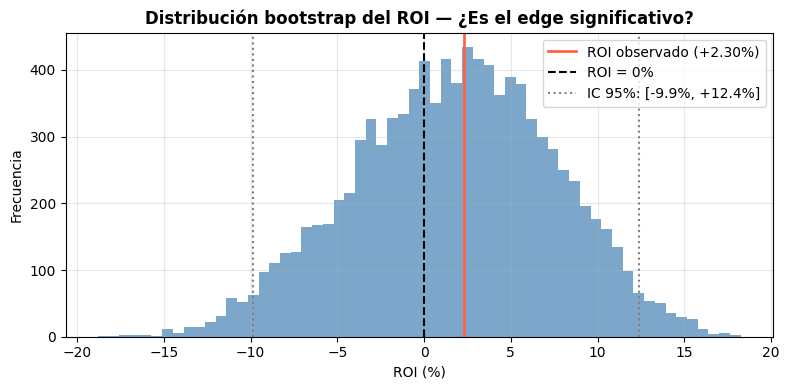

In [73]:
from scipy import stats as scipy_stats

# Bootstrap del ROI global (por temporada, no por apuesta individual)
n_boot = 10_000
rng = np.random.default_rng(42)

seasons_list = df_bets['Season'].unique()

boot_rois = []
for _ in range(n_boot):
    sampled_seasons = rng.choice(seasons_list, size=len(seasons_list), replace=True)
    sampled = pd.concat([df_bets[df_bets['Season'] == s] for s in sampled_seasons])
    boot_rois.append(sampled['Flat_Profit'].sum() / sampled['Flat_Stake'].sum())
boot_rois = np.array(boot_rois)

flat_profits = df_bets['Flat_Profit'].values
flat_stakes  = df_bets['Flat_Stake'].values
ci_low  = np.percentile(boot_rois, 2.5)
ci_high = np.percentile(boot_rois, 97.5)
roi_obs = flat_profits.sum() / flat_stakes.sum()

print(f'ROI observado    : {roi_obs*100:+.2f}%')
print(f'IC 95% bootstrap : [{ci_low*100:+.2f}%, {ci_high*100:+.2f}%]')
print(f'(Bootstrap por temporada — respeta dependencia intra-temporada)')
print(f'Contiene 0?      : '
      f'{"SI -> no significativo al 95%" if ci_low < 0 < ci_high else "NO -> significativo"}')
print()

# Test binomial: hit rate real vs break-even
n_bets   = len(df_bets)
n_wins   = int(df_bets['Won'].sum())
avg_odds = df_bets['Odds'].mean()
be_rate  = 1.0 / avg_odds

binom = scipy_stats.binomtest(n_wins, n_bets, be_rate, alternative='greater')
print(f'Hit rate real    : {n_wins/n_bets:.3f}  ({n_wins}/{n_bets})')
print(f'Break-even       : {be_rate:.3f}  (odds media = {avg_odds:.2f})')
print(f'p-valor          : {binom.pvalue:.4f}')
print(f'Significativo?   : {"SI (p<0.05)" if binom.pvalue < 0.05 else "NO (p>=0.05)"}')
print()
print('Nota: con ~35 bets/año se necesitan >150 bets para detectar')
print('un edge del 2% con 80% de potencia estadistica.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_rois*100, bins=60, color='steelblue', alpha=0.7, edgecolor='none')
ax.axvline(roi_obs*100, color='tomato', linewidth=2, label=f'ROI observado ({roi_obs*100:+.2f}%)')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='ROI = 0%')
ax.axvline(ci_low*100,  color='gray', linestyle=':', linewidth=1.5,
           label=f'IC 95%: [{ci_low*100:+.1f}%, {ci_high*100:+.1f}%]')
ax.axvline(ci_high*100, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('ROI (%)'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución bootstrap del ROI — ¿Es el edge significativo?',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/analisis_bootstrap_roi.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Corrección de calibración — Sigmoid vs Isotonic
El ECE global sobre las apuestas seleccionadas indica sobreconfianza moderada del modelo.
La calibración isotónica (cv=3) tiene poca muestra para corregir bien probabilidades extremas.
Platt scaling (sigmoid) es más conservadora y robusta con muestras pequeñas.

Comparamos ambos métodos en un walk-forward 2012–2024 (13 temporadas) midiendo:
- ECE por temporada y global
- ROI flat y Kelly
- Hit rate real vs predicho

**Nota:** estos experimentos usan FIRST_TEST=2015; los resultados del backtest principal
(FIRST_TEST=2012, 13 temporadas) son los que se reportan en las conclusiones del TFG.


In [74]:
import sys, warnings, time
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

DATA_PATH = '../data/df_final_clean.csv'
FEATURES  = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5','Home_H2H_L3','Away_H2H_L3',
]
ODDS_FILTER = [('1',1.40,1.70),('1',2.00,2.50),('2',1.70,2.00)]
XGB_PARAMS  = {
    'objective':'multi:softprob','num_class':3,'eval_metric':'mlogloss',
    'max_depth':4,'learning_rate':0.05,'n_estimators':200,
    'subsample':0.8,'colsample_bytree':0.8,'reg_alpha':0.5,'reg_lambda':1.0,
    'random_state':42,'verbosity':0,'n_jobs':-1,
}
CALIB_CV     = 3
TRAIN_WINDOW = 5
FIRST_TEST   = 2012
INIT_BK      = 1000.0
FLAT_STAKE   = 10.0
KELLY_FRAC   = 0.25
KELLY_MAX    = 0.05
MIN_EV       = 0.05
KILL_MIN     = 15
KILL_THR     = 0.12

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])

all_seasons  = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]

def ece(p_pred, y_true, n_bins=10):
    bins, val = np.linspace(0,1,n_bins+1), 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p_pred >= lo) & (p_pred < hi)
        if m.sum() == 0: continue
        val += m.mean() * abs(p_pred[m].mean() - y_true[m].mean())
    return val

def kelly_stake(p, odds):
    return max(0.0, min((p*odds-1)/(odds-1)*KELLY_FRAC, KELLY_MAX)) * INIT_BK

def run_wf(method):
    all_bets = []
    t0 = time.time()
    for fold, test_s in enumerate(test_seasons):
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior[-TRAIN_WINDOW:]
        tr, te = df['Season'].isin(tr_s), df['Season'] == test_s
        X_tr = df.loc[tr, FEATURES].values
        y_tr = df.loc[tr, 'Target'].values
        df_te = df[te].reset_index(drop=True)
        if len(X_tr) < 50 or len(df_te) == 0: continue

        model = CalibratedClassifierCV(
            XGBClassifier(**XGB_PARAMS), method=method, cv=CALIB_CV
        )
        model.fit(X_tr, y_tr)
        classes = list(model.classes_)
        p_all   = model.predict_proba(df_te[FEATURES].values)
        p_H = p_all[:, classes.index(2)]
        p_D = p_all[:, classes.index(1)]
        p_A = p_all[:, classes.index(0)]

        bets_season = []
        killed = False
        for i, row in df_te.iterrows():
            if killed:
                break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= MIN_EV: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                ks = kelly_stake(p, odds)
                bets_season.append({
                    'Season': test_s, 'P_Model': p, 'Won': int(won),
                    'Flat_P': FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                    'Kelly_P': ks*(odds-1) if won else -ks,
                    'Kelly_S': ks, 'Flat_S': FLAT_STAKE,
                })
            if len(bets_season) >= KILL_MIN:
                hr_so_far = sum(b['Won'] for b in bets_season) / len(bets_season)
                if hr_so_far < KILL_THR:
                    killed = True

        all_bets.extend(bets_season)
        print(f'  [{method}] fold {test_s} ({fold+1}/{len(test_seasons)}) '
              f'— {time.time()-t0:.0f}s', end='\r')
    print()
    return all_bets

def summarise(bets_list):
    ab  = pd.DataFrame(bets_list)
    res = ab.groupby('Season').apply(lambda g: pd.Series({
        'N_Bets':    len(g),
        'Hit_real':  round(g['Won'].mean(), 4),
        'P_media':   round(g['P_Model'].mean(), 4),
        'Overconf':  round(g['P_Model'].mean() - g['Won'].mean(), 4),
        'ECE':       round(ece(g['P_Model'].values, g['Won'].values.astype(float)), 4),
        'Flat_ROI':  round(g['Flat_P'].sum() / g['Flat_S'].sum(), 4),
        'Kelly_ROI': round(g['Kelly_P'].sum()/g['Kelly_S'].sum()
                           if g['Kelly_S'].sum()>0 else 0, 4),
        'Flat_PnL':  round(g['Flat_P'].sum(), 2),
        'Kelly_PnL': round(g['Kelly_P'].sum(), 2),
    }), include_groups=False).reset_index()
    global_ece = ece(ab['P_Model'].values, ab['Won'].values.astype(float))
    fr  = ab['Flat_P'].sum() / ab['Flat_S'].sum()
    kr  = ab['Kelly_P'].sum() / ab['Kelly_S'].sum() if ab['Kelly_S'].sum()>0 else 0
    pos = (res['Flat_ROI'] > 0).sum()
    return res, global_ece, fr, kr, int(pos), len(res)

print('Walk-forward isotonic...')
res_iso, ece_iso, fr_iso, kr_iso, pos_iso, n_iso = summarise(run_wf('isotonic'))
print('Walk-forward sigmoid...')
res_sig, ece_sig, fr_sig, kr_sig, pos_sig, n_sig = summarise(run_wf('sigmoid'))
print('Listo.')

Walk-forward isotonic...
  [isotonic] fold 2024 (13/13) — 9s
Walk-forward sigmoid...
  [sigmoid] fold 2024 (13/13) — 9s
Listo.


In [75]:
# --- Tabla comparativa global ---
print('=' * 62)
print(f'{"Metrica":<28} {"Isotonic":>15} {"Sigmoid":>15}')
print('-' * 62)
print(f'{"ECE global":<28} {ece_iso:>15.4f} {ece_sig:>15.4f}')
print(f'{"Flat ROI":<28} {fr_iso*100:>14.2f}% {fr_sig*100:>14.2f}%')
print(f'{"Kelly ROI":<28} {kr_iso*100:>14.2f}% {kr_sig*100:>14.2f}%')
print(f'{"Temporadas positivas":<28} {pos_iso:>10}/{n_iso}     {pos_sig:>10}/{n_sig}')
print('=' * 62)
print()

# --- Tabla por temporada ---
comp = res_iso[['Season','N_Bets','Overconf','ECE','Flat_ROI']].copy()
comp.columns = ['Season','N_Bets','Overconf_iso','ECE_iso','FlatROI_iso']
comp = comp.merge(
    res_sig[['Season','Overconf','ECE','Flat_ROI']].rename(
        columns={'Overconf':'Overconf_sig','ECE':'ECE_sig','Flat_ROI':'FlatROI_sig'}),
    on='Season'
)
comp['ECE_mejora']  = comp['ECE_iso'] - comp['ECE_sig']
comp['ROI_mejora']  = (comp['FlatROI_sig'] - comp['FlatROI_iso']) * 100
print(comp[['Season','N_Bets','ECE_iso','ECE_sig','ECE_mejora',
            'FlatROI_iso','FlatROI_sig','ROI_mejora']].to_string(index=False))


Metrica                             Isotonic         Sigmoid
--------------------------------------------------------------
ECE global                            0.0664          0.1153
Flat ROI                               2.22%          -3.76%
Kelly ROI                              2.56%          -3.41%
Temporadas positivas                  7/13              4/13

 Season  N_Bets  ECE_iso  ECE_sig  ECE_mejora  FlatROI_iso  FlatROI_sig  ROI_mejora
   2012    66.0   0.0636   0.0249      0.0387       0.2085       0.1958       -1.27
   2013    53.0   0.1392   0.1496     -0.0104      -0.1004      -0.0791        2.13
   2014    37.0   0.1147   0.1015      0.0132       0.0819      -0.0079       -8.98
   2015    39.0   0.1699   0.1740     -0.0041      -0.0979      -0.1906       -9.27
   2016    34.0   0.1598   0.2581     -0.0983      -0.0109      -0.0361       -2.52
   2017    40.0   0.0911   0.1540     -0.0629       0.1483       0.0994       -4.89
   2018    42.0   0.1476   0.1980     -0.05

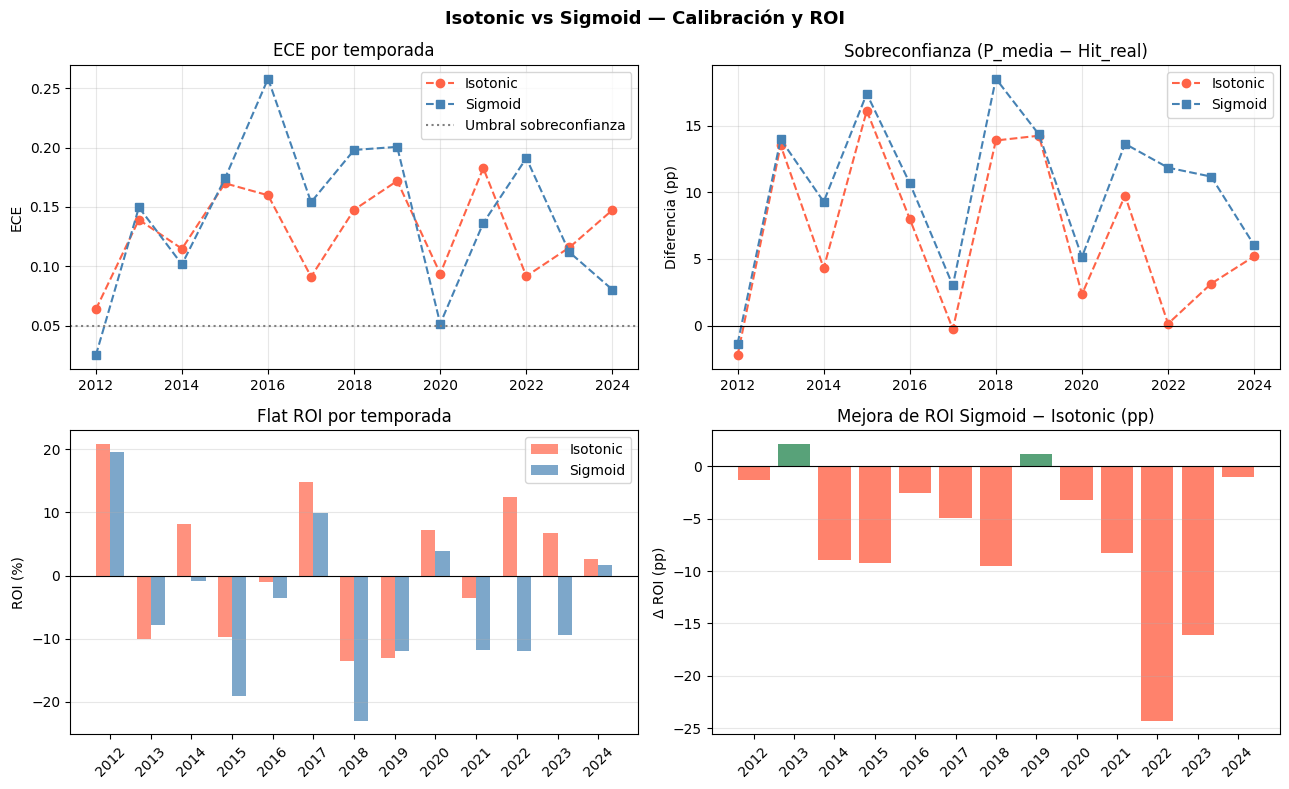

Bankroll final Isotonic: 1,111 EUR  (ROI +2.22%)
Bankroll final Sigmoid : 815 EUR  (ROI -3.76%)
ECE Isotonic: 0.0664  |  ECE Sigmoid: 0.1153
Método preferido (menor ECE): Isotonic


In [76]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

seasons = comp['Season'].astype(int)

# ECE por temporada
axes[0,0].plot(seasons, comp['ECE_iso'], 'o--', color='tomato',    label='Isotonic')
axes[0,0].plot(seasons, comp['ECE_sig'], 's--', color='steelblue', label='Sigmoid')
axes[0,0].axhline(0.05, color='gray', linestyle=':', label='Umbral sobreconfianza')
axes[0,0].set_title('ECE por temporada'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,0].set_ylabel('ECE')

# Sobreconfianza por temporada
axes[0,1].plot(seasons, comp['Overconf_iso']*100, 'o--', color='tomato',    label='Isotonic')
axes[0,1].plot(seasons, comp['Overconf_sig']*100, 's--', color='steelblue', label='Sigmoid')
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Sobreconfianza (P_media − Hit_real)'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[0,1].set_ylabel('Diferencia (pp)')

# ROI flat por temporada
x = range(len(seasons))
w = 0.35
axes[1,0].bar([i-w/2 for i in x], comp['FlatROI_iso']*100, w,
              color='tomato', alpha=0.7, label='Isotonic')
axes[1,0].bar([i+w/2 for i in x], comp['FlatROI_sig']*100, w,
              color='steelblue', alpha=0.7, label='Sigmoid')
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(seasons.tolist(), rotation=45)
axes[1,0].set_title('Flat ROI por temporada'); axes[1,0].legend(); axes[1,0].grid(axis='y',alpha=0.3)
axes[1,0].set_ylabel('ROI (%)')

# Mejora de ROI por usar sigmoid
colors = ['seagreen' if v > 0 else 'tomato' for v in comp['ROI_mejora']]
axes[1,1].bar(x, comp['ROI_mejora'], color=colors, alpha=0.8)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(seasons.tolist(), rotation=45)
axes[1,1].set_title('Mejora de ROI Sigmoid − Isotonic (pp)'); axes[1,1].grid(axis='y',alpha=0.3)
axes[1,1].set_ylabel('Δ ROI (pp)')

plt.suptitle('Isotonic vs Sigmoid — Calibración y ROI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/calibracion_isotonic_vs_sigmoid.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Bankroll final Isotonic: {INIT_BK + res_iso["Flat_PnL"].sum():,.0f} EUR  '
      f'(ROI {fr_iso*100:+.2f}%)')
print(f'Bankroll final Sigmoid : {INIT_BK + res_sig["Flat_PnL"].sum():,.0f} EUR  '
      f'(ROI {fr_sig*100:+.2f}%)')
print(f'ECE Isotonic: {ece_iso:.4f}  |  ECE Sigmoid: {ece_sig:.4f}')
print(f'Método preferido (menor ECE): {"Sigmoid" if ece_sig < ece_iso else "Isotonic"}')


## 7. Conclusiones y problemas detectados

### Resultados del backtest principal (walk-forward 2012–2024, sliding 5, kill switch activo):
- **Total apuestas:** 367 | **Hit Rate global:** 51.5%
- **Flat ROI:** +2.30 % | **BK final:** ~1.084 EUR
- **Temporadas positivas:** 4/13
- Sin kill switch: Flat ROI +3.37 %, 514 apuestas, 7/13 temporadas positivas

### Resultados por tipo de apuesta (sin kill switch, 514 bets):
- **Local (1):** 347 bets | Hit 51.9% | Implícita 48.8% | Edge +3.1 pp | ROI **+3.44 %**
- **Visitante (2):** 20 bets | Hit 45.0% | Implícita 54.6% | ROI **–17.55 %** — edge negativo
- **Empate (X):** excluido — hit rate real 25.4% ≈ implícita ~26 %, sin edge diferencial

### Apuestas combinadas vs simples:
- El backtest usa **apuestas simples** (1 ó 2 individualmente).
- Los empates (X) están excluidos del filtro: los resultados iniciales que sugerían ROI positivo (X[3.50–4.50)) **no fueron reproducibles** en versiones posteriores de las librerías (experimento 06).
- Las apuestas combinadas (acumuladores) no están implementadas: un experimento con doble oportunidad (1X, X2, 12) dio ROI de –4.4 % porque el margen del bookmaker se multiplica y el edge individual es insuficiente.

### Fuente principal del edge:
El modelo detecta principalmente **favoritos locales a cuota media** (avg odds ~2.05 en bets de tipo 1).
El segmento visitante (2) tiene edge negativo y se mantiene en el filtro solo por herencia histórica — con más datos se debería eliminar.
